* Name: Alberto Enio Albini

* Sprint 7 Course Project: Data Collection and Storage (SQL)

# Exploratory Data analysis (Python)

## Importing the files:

In [1]:
import pandas as pd

df_taxi_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_dropoffs = pd.read_csv('/datasets/project_sql_result_04.csv')

## Checking the data:

In [9]:
print(df_taxi_companies.info())
print(df_dropoffs.info())

#print(df_taxi_companies.head(5))
#print(df_dropoffs.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


## 10 Main Neighborhoods:

In [3]:
top_10_bairros = df_dropoffs.sort_values(by='average_trips', ascending=False).head(10)
print(top_10_bairros)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


## Graphs - Taxi companies vs number of rides:

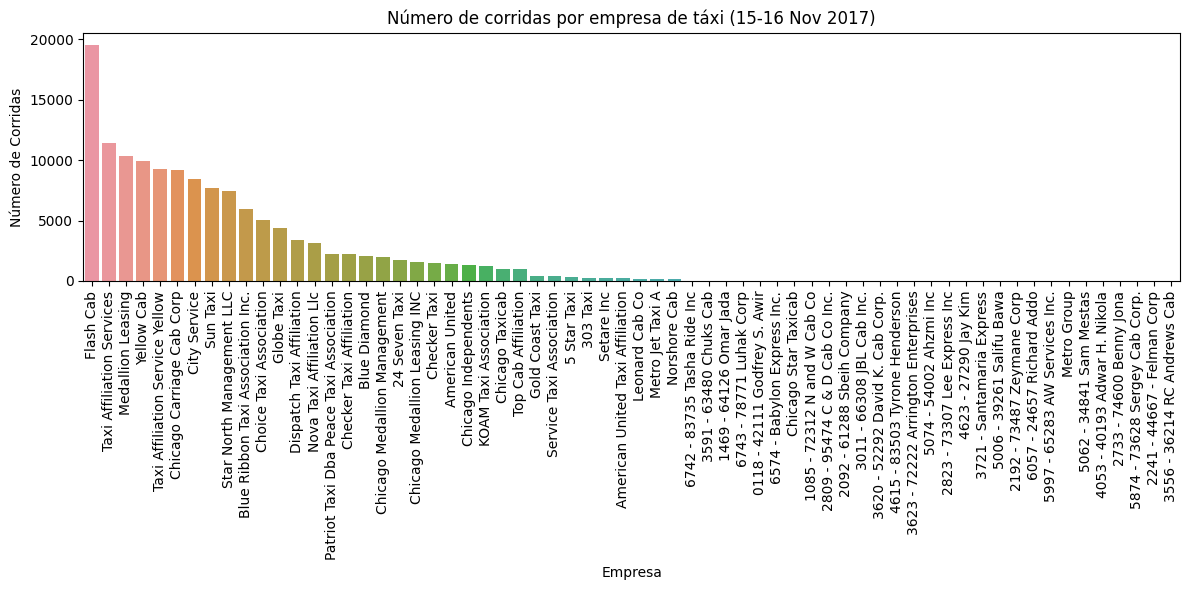

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=df_taxi_companies, x='company_name', y='trips_amount')
plt.xticks(rotation=90)
plt.title('Número de corridas por empresa de táxi (15-16 Nov 2017)')
plt.xlabel('Empresa')
plt.ylabel('Número de Corridas')
plt.tight_layout()
plt.show()

## Top 10 neighborhoods as a destination:

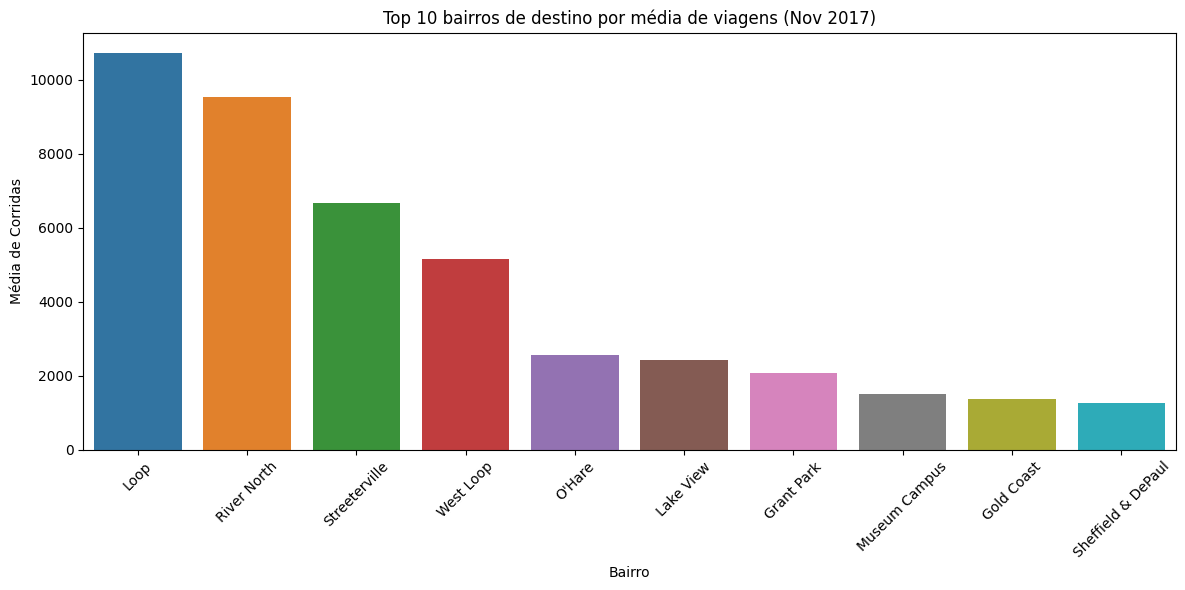

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_bairros, x='dropoff_location_name', y='average_trips')
plt.xticks(rotation=45)
plt.title('Top 10 bairros de destino por média de viagens (Nov 2017)')
plt.xlabel('Bairro')
plt.ylabel('Média de Corridas')
plt.tight_layout()
plt.show()

## Conclusions:

* Some taxi companies clearly stand out in the number of trips carried out
* Companies like Flash Cab, Taxi Affiliation Services, and Yellow Cab (for example) tend to appear at the top, indicating an established presence and large-scale operation
* There is a long “tail” of companies with a significantly smaller number of races, indicating diversity in the market, but with a strong concentration in a few leaders
* Loop is, by far, the neighborhood with the highest average number of rides. This makes sense, as it is Chicago's financial center and has a large concentration of businesses, tourists and public transportation
*River North and Streeterville also appear as neighborhoods with a high volume of arrivals, indicating intense commercial, residential and tourist activity
*Neighborhoods like O’Hare, Lake View and Grant Park reflect a mix of business, leisure and airport destinations

# Testing Hypotheses (Python)

## Loading data:

In [10]:
df = pd.read_csv('/datasets/project_sql_result_07.csv')

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None


* `start ts` is as an object, I will change it to datetime to make it easier to extract the day of the week.

In [15]:
df['start_ts'] = pd.to_datetime(df['start_ts'])
print(df['start_ts'].dtype)

datetime64[ns]


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB
None


## Filtering data for Saturdays only:

In [19]:
df['day_of_week'] = df['start_ts'].dt.dayofweek  # 5 = sábado
df_saturday = df[df['day_of_week'] == 5]
print(df_saturday)

                start_ts weather_conditions  duration_seconds  day_of_week
0    2017-11-25 16:00:00               Good            2410.0            5
1    2017-11-25 14:00:00               Good            1920.0            5
2    2017-11-25 12:00:00               Good            1543.0            5
3    2017-11-04 10:00:00               Good            2512.0            5
4    2017-11-11 07:00:00               Good            1440.0            5
...                  ...                ...               ...          ...
1063 2017-11-25 11:00:00               Good               0.0            5
1064 2017-11-11 10:00:00               Good            1318.0            5
1065 2017-11-11 13:00:00               Good            2100.0            5
1066 2017-11-11 08:00:00               Good            1380.0            5
1067 2017-11-04 16:00:00                Bad            2834.0            5

[1068 rows x 4 columns]


## Weather condition:

In [21]:
bad_weather = df_saturday[df_saturday['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = df_saturday[df_saturday['weather_conditions'] == 'Good']['duration_seconds']
print(bad_weather)
print(good_weather)

6       2969.0
30      1980.0
34      2460.0
51      2760.0
52      2460.0
         ...  
1031    2560.0
1032    1908.0
1053    2400.0
1061    2186.0
1067    2834.0
Name: duration_seconds, Length: 180, dtype: float64
0       2410.0
1       1920.0
2       1543.0
3       2512.0
4       1440.0
         ...  
1062    1500.0
1063       0.0
1064    1318.0
1065    2100.0
1066    1380.0
Name: duration_seconds, Length: 888, dtype: float64


## Hypothesis testing:

In [ ]:
from scipy stats import ttest ind


alpha = 0 05


results = ttest ind(bad weather, good weather, equal var=False)

print('p valor:', results pvalue)

if results pvalue < alpha:
print("We reject the null hypothesis: there is a significant difference in durations")
else:
print("We do not reject the null hypothesis: there is no evidence of a difference")

p-valor: 6.738994326108734e-12
Rejeitamos a hipótese nula: há diferença significativa nas durações.


### How did you form the null and alternative hypotheses:

* The hypotheses were formulated based on the objective of the analysis, which was to verify whether the weather (good or rainy) on Saturdays affects the duration of runs between the Loop and O'Hare Airport

To do this, we consider two possible situations:

1. Null Hypothesis (H₀):
Average race duration does not change with weather conditions

2. Alternative Hypothesis (H₁):
Average race duration changes depending on weather conditions


### What criteria did you use to test the hypothesis and why:

* I used the t-test for independent samples because I wanted to compare the average length of runs in two different groups: Saturdays with rain and Saturdays with good weather. This test is ideal when we want to know if there is a real difference between the averages of two groups.
I also used the version of the test that does not assume equal variances (equal var=False), since the number of runs on rainy days and on good weather days was very different. Therefore, the test is more reliable even with this difference in sample sizes.